# Python Visualizations & Business Insights
## Project: Willy Wonka Chocolate Factory
## Purpose: Use Python to visualize SQL-based business insights

In [3]:
#! pip install pymysql

import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
# MySQL Connection
# This connection allows Python to query the relational database
# created in MySQL Workbench.

#!pip install cryptography
#connection = pymysql.connect(
    host="localhost",
    user="root",
    #password="***",
    database="wonka_choc_factory"
)

In [8]:
# Visualization 1: Top 10 Products by Revenue

# Business question:
# Which products generate the highest revenue?
#
# This query aggregates sales and profit by product.
# The goal is to identify the strongest revenue-generating products.

query_top_products = """
SELECT
    p.product_name,
    ROUND(SUM(od.sales), 2) AS total_revenue,
    ROUND(SUM(od.gross_profit), 2) AS total_profit,
    SUM(od.units) AS total_units_sold
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query_top_products, connection)

top_products

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\3588618629.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_products = pd.read_sql(query_top_products, connection)


,product_name,total_revenue,total_profit,total_units_sold
0,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596.0
1,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743.0
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267.0
3,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914.0
4,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.0
5,Lickable Wallpaper,7860.00,3930.00,393.0
6,Kazookles,1205.75,92.75,371.0
7,Wonka Gum,597.50,310.70,478.0
8,Everlasting Gobstopper,130.00,104.00,13.0
9,Fizzy Lifting Drinks,78.75,47.25,21.0


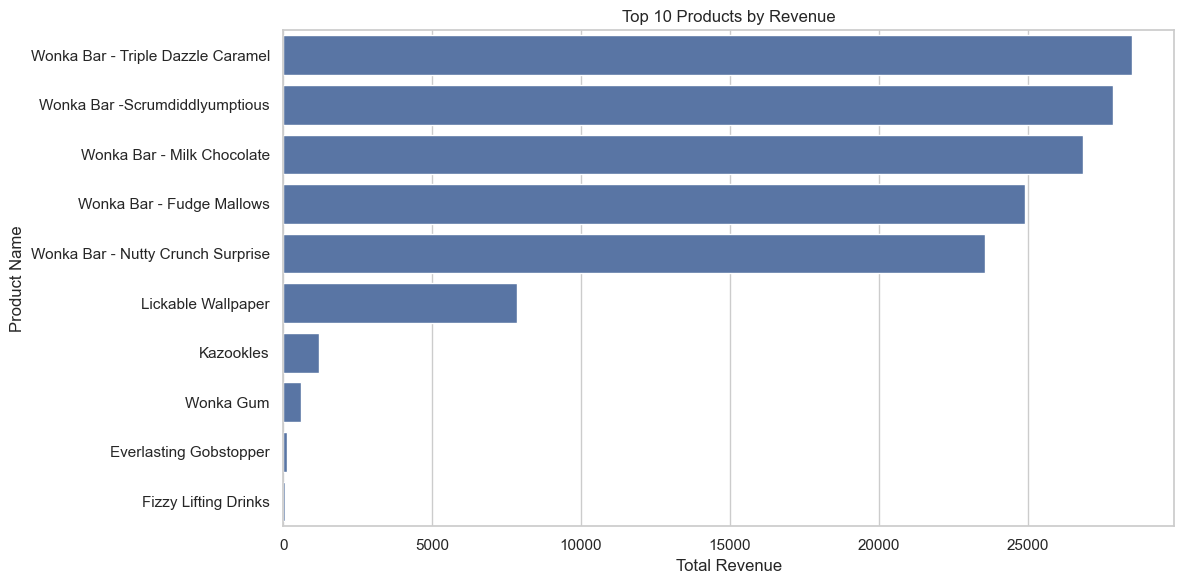

In [9]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_products,
    x="total_revenue",
    y="product_name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### Insight

The chart highlights the products generating the highest revenue.  
These products represent the strongest commercial performers and should be prioritized for inventory planning, promotional strategies, and business growth decisions.

In [10]:
# Visualization 2: Regional Sales and Profit Performance

# Business question:
# Which regions contribute most to overall sales and profitability?
#
# This query aggregates revenue, profit, and units sold by region.

query_region_performance = """
SELECT
    l.region,
    ROUND(SUM(od.sales), 2) AS total_revenue,
    ROUND(SUM(od.gross_profit), 2) AS total_profit,
    SUM(od.units) AS total_units_sold
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
JOIN locations l
    ON o.location_id = l.location_id
GROUP BY l.region
ORDER BY total_revenue DESC;
"""

region_performance = pd.read_sql(query_region_performance, connection)

region_performance

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\315434871.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  region_performance = pd.read_sql(query_region_performance, connection)


,region,total_revenue,total_profit,total_units_sold
0,Pacific,46301.53,30485.94,12466.0
1,Atlantic,41197.24,26973.70,11159.0
2,Interior,32037.60,21282.49,8820.0
3,Gulf,22247.26,14700.67,6209.0


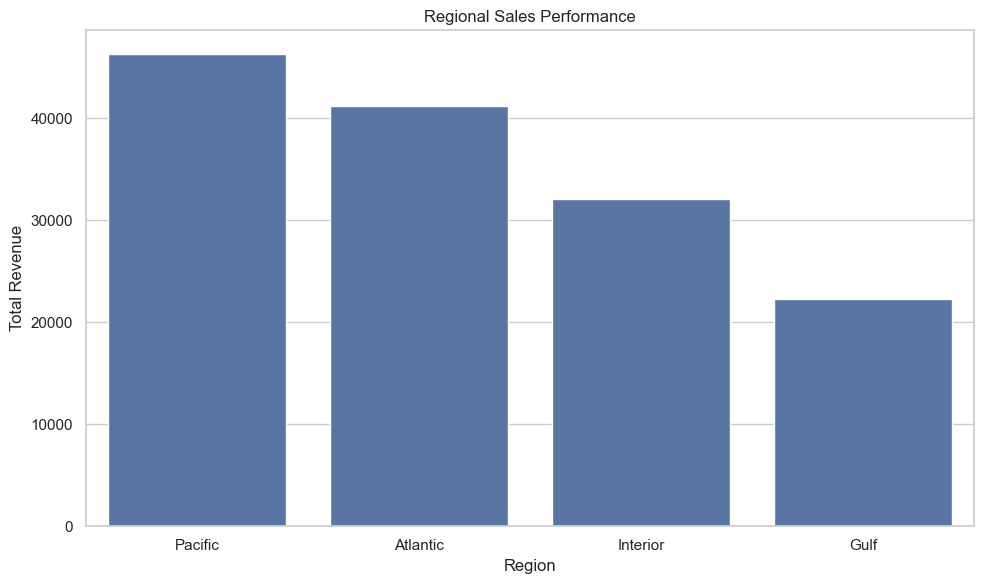

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_performance,
    x="region",
    y="total_revenue"
)

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Insight

This visualization shows which regions generate the highest revenue.  
High-performing regions may represent stronger customer demand, better market positioning, or more effective distribution opportunities.

In [12]:
# Visualization 3: Factory Profitability Analysis

# Business question:
# Which factories generate the highest profit?
#
# This query connects factories with products and sales metrics
# to evaluate factory-level profitability.

query_factory_profitability = """
SELECT
    f.factory_name,
    ROUND(SUM(od.sales), 2) AS total_revenue,
    ROUND(SUM(od.gross_profit), 2) AS total_profit,
    SUM(od.units) AS total_units_sold,
    ROUND(AVG(od.gross_profit), 2) AS avg_profit_per_transaction
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
JOIN factories f
    ON p.factory_id = f.factory_id
GROUP BY f.factory_name
ORDER BY total_profit DESC;
"""

factory_profitability = pd.read_sql(query_factory_profitability, connection)

factory_profitability

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\2766383887.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  factory_profitability = pd.read_sql(query_factory_profitability, connection)


,factory_name,total_revenue,total_profit,total_units_sold,avg_profit_per_transaction
0,Lot's O' Nuts\r,76340.15,52771.05,21412.0,9.27
1,Wicked Choccy's\r,55352.75,36053.57,15863.0,8.68
2,Secret Factory\r,8587.50,4344.70,884.0,20.02
3,The Other Factory\r,1282.25,152.25,388.0,1.52
4,Sugar Shack\r,220.98,121.23,107.0,3.67


) missing from font(s) Arial.Temp\ipykernel_25000\3748274699.py:14: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


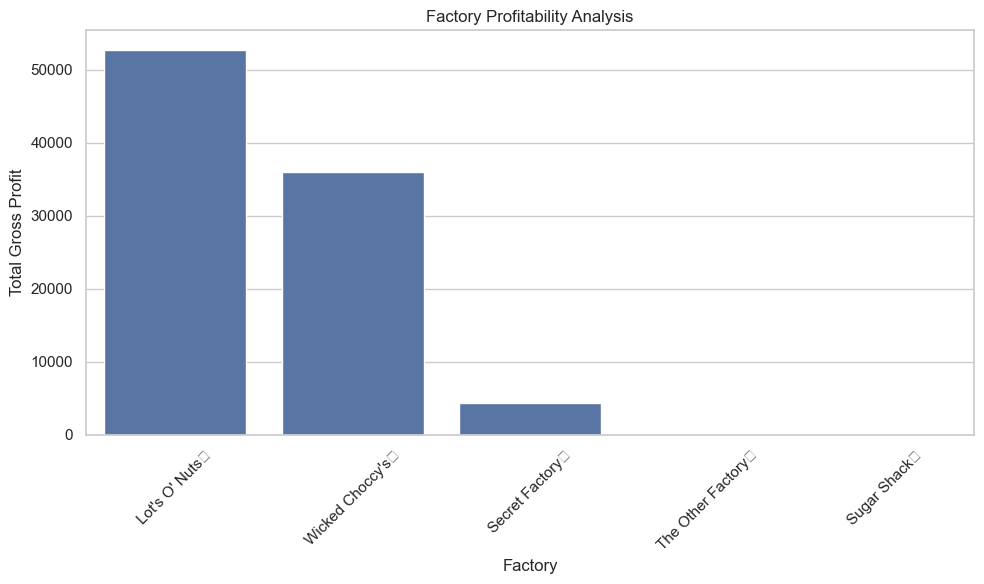

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=factory_profitability,
    x="factory_name",
    y="total_profit"
)

plt.title("Factory Profitability Analysis")
plt.xlabel("Factory")
plt.ylabel("Total Gross Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

This chart compares factories based on total gross profit.  
Factories with lower profitability may require operational review, product mix analysis, or cost-efficiency improvements.

In [14]:
# Visualization 4: Monthly Revenue Trend

# Business question:
# How does revenue evolve over time?
#
# This query aggregates sales by month to identify revenue trends.

query_monthly_trend = """
SELECT
    DATE_FORMAT(o.order_date, '%Y-%m') AS order_month,
    ROUND(SUM(od.sales), 2) AS monthly_revenue,
    ROUND(SUM(od.gross_profit), 2) AS monthly_profit,
    SUM(od.units) AS monthly_units_sold
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
GROUP BY DATE_FORMAT(o.order_date, '%Y-%m')
ORDER BY order_month;
"""

monthly_trend = pd.read_sql(query_monthly_trend, connection)

monthly_trend.head()

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\1901712722.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_trend = pd.read_sql(query_monthly_trend, connection)


,order_month,monthly_revenue,monthly_profit,monthly_units_sold
0,2021-01,1065.24,704.00,306.0
1,2021-02,547.09,358.07,159.0
2,2021-03,2245.63,1425.29,597.0
3,2021-04,2058.97,1325.13,536.0
4,2021-05,1855.21,1208.23,504.0


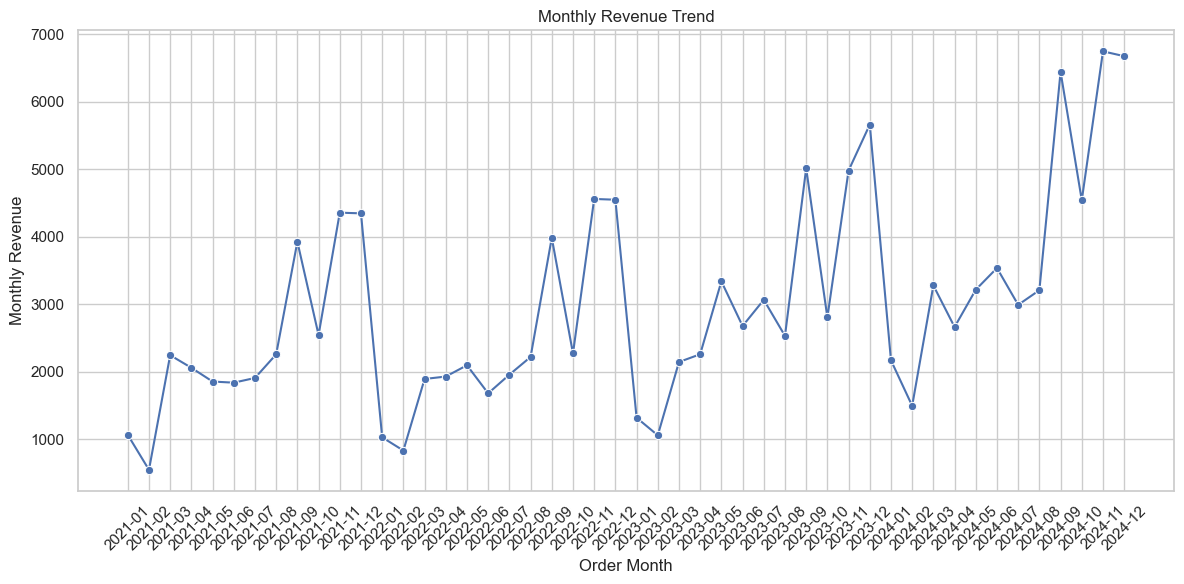

In [15]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_trend,
    x="order_month",
    y="monthly_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Order Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

The monthly revenue trend helps identify seasonality, growth patterns, or possible sales fluctuations over time.  
This can support production planning and marketing campaign timing.

In [16]:
# Visualization 5: Product Profit Margin Analysis

# Business question:
# Which products generate stronger profit margins?
#
# This query calculates profit margin as:
# gross profit / sales * 100

query_profit_margin = """
SELECT
    p.product_name,
    ROUND(SUM(od.sales), 2) AS total_revenue,
    ROUND(SUM(od.gross_profit), 2) AS total_profit,
    ROUND((SUM(od.gross_profit) / SUM(od.sales)) * 100, 2) AS profit_margin_percentage
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY profit_margin_percentage DESC;
"""

profit_margin = pd.read_sql(query_profit_margin, connection)

profit_margin.head()

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\4281832512.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  profit_margin = pd.read_sql(query_profit_margin, connection)


,product_name,total_revenue,total_profit,profit_margin_percentage
0,Everlasting Gobstopper,130.00,104.00,80.00
1,Hair Toffee,76.50,59.50,77.78
2,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35
3,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67


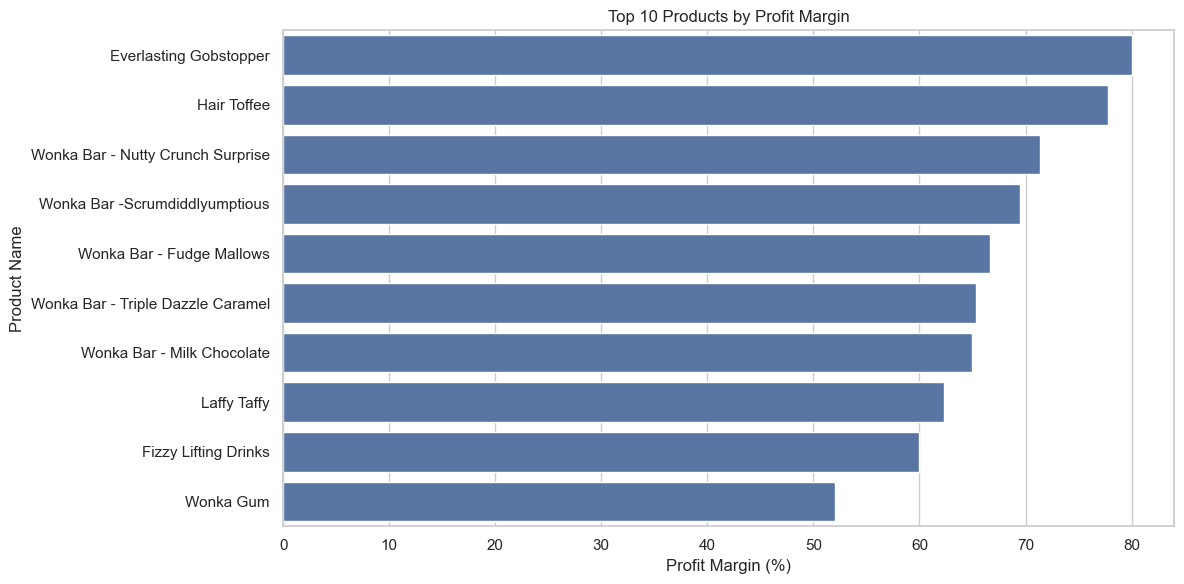

In [17]:
top_margin_products = profit_margin.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_margin_products,
    x="profit_margin_percentage",
    y="product_name"
)

plt.title("Top 10 Products by Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### Insight

This chart identifies products with the strongest profit margins.  
A product with high revenue is not always the most efficient product, so margin analysis helps identify products that contribute more effectively to profitability.

In [18]:
# Visualization 6: Shipping Mode Performance

# Business question:
# Which shipping modes are associated with the highest revenue?
#
# This query compares sales performance by shipping mode.

query_shipping_mode = """
SELECT
    o.ship_mode,
    COUNT(o.order_id) AS number_of_orders,
    ROUND(SUM(od.sales), 2) AS total_revenue,
    ROUND(SUM(od.gross_profit), 2) AS total_profit,
    ROUND(AVG(od.sales), 2) AS avg_order_value
FROM orders o
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY o.ship_mode
ORDER BY total_revenue DESC;
"""

shipping_mode = pd.read_sql(query_shipping_mode, connection)

shipping_mode

C:\Users\estef\AppData\Local\Temp\ipykernel_25000\2069033719.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  shipping_mode = pd.read_sql(query_shipping_mode, connection)


,ship_mode,number_of_orders,total_revenue,total_profit,avg_order_value
0,Standard Class\r,6120,85490.35,56424.46,13.97
1,Second Class\r,1979,27860.22,18306.52,14.08
2,First Class\r,1548,21319.39,14011.09,13.77
3,Same Day\r,547,7113.67,4700.73,13.00


) missing from font(s) Arial.Temp\ipykernel_25000\2543725597.py:14: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


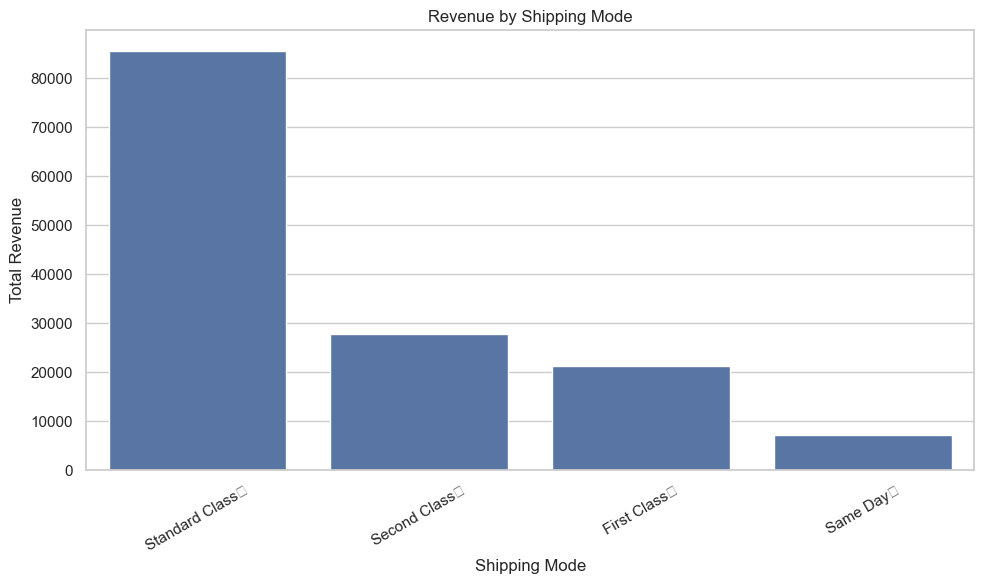

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shipping_mode,
    x="ship_mode",
    y="total_revenue"
)

plt.title("Revenue by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Insight

Shipping mode analysis helps understand whether certain logistics methods are associated with stronger sales performance.  
This can support operational and delivery strategy decisions.

# Final Business Conclusions

The SQL and Python analysis revealed several important business insights for the Willy Wonka Chocolate Factory:

- Revenue is concentrated among a group of high-performing chocolate products.
- Regional performance is uneven, suggesting that some regions represent stronger business opportunities.
- Factory profitability differs significantly, indicating potential operational efficiency gaps.
- Profit margin analysis shows that the most profitable products are not always the same as the highest-revenue products.
- Shipping mode performance can help the company evaluate logistics patterns and customer behavior.

Overall, the relational database structure allowed the team to move from raw transactional data to actionable business intelligence.

In [20]:
# Close the MySQL connection after completing the analysis
connection.close()